In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split



In [8]:
RNG = np.random.default_rng(42)

# =============================================================================
# PARÁMETROS CAUSALES — conocidos por construcción
# =============================================================================
TAU_TRUE  = 0.08   # efecto causal de X1 sobre P(default)
RHO       = 0.6    # correlación entre clase latente y X1 → endogeneidad

# =============================================================================
# PART 1 — Mezcla gaussiana para X2, X3, X4
# =============================================================================
N_FEATURES = 3

delta_g = [0.6, 0.4]
mu_g    = [np.array([-0.4, -0.2, -0.3]),
           np.array([-0.2, -0.4,  0.2])]
cov_g   = [np.eye(N_FEATURES) * 1.2,
           np.eye(N_FEATURES) * 1.3]

delta_b = [0.5, 0.5]
mu_b    = [np.array([ 0.4,  0.3,  0.2]),
           np.array([ 0.2,  0.5, -0.1])]
cov_b   = [np.eye(N_FEATURES) * 1.2,
           np.eye(N_FEATURES) * 1.3]

def sample_mixture(n, mus, covs, deltas, rng):
    components = rng.choice(len(deltas), size=n, p=deltas)
    return np.vstack([rng.multivariate_normal(mus[c], covs[c]) for c in components])

N_BATCH = 100
P_BAD   = 0.30

def sample_batch(n, p_bad, rng, tau_true=TAU_TRUE, rho=RHO):
    """
    ESCENARIO B — X1 endógena.

    Estructura causal:
        U  ~ N(0,1)             variable latente no observada (ej. riqueza)
        X1 = rho*U + sqrt(1-rho²)*V,  V~N(0,1)  → X1 correlacionada con U
        Y  ~ Bernoulli(σ(base + tau_true*X1 + U))  → U afecta Y directamente
        Z  ~ alpha*U_z + X1*0.7 + ruido            → instrumento: correlacionado
                                                       con X1 pero no con Y|X,U

    Porque U entra tanto en X1 como en Y, una regresión de Y sobre X1
    captura tau_true + efecto de U → τ estimado ≠ τ* sin corrección.
    Heckman usa Z para separar el efecto de U del efecto de X1.
    """
    n_bad  = rng.binomial(n, p_bad)
    n_good = n - n_bad

    # X2, X3, X4 — confounders observados (dependen de clase)
    X_rest = np.vstack([
        sample_mixture(n_good, mu_g, cov_g, delta_g, rng),
        sample_mixture(n_bad,  mu_b, cov_b, delta_b, rng),
    ])

    # Variable latente no observada — correlacionada con clase
    # U es más alto para los malos → confounding
    U_good = rng.normal(-0.5, 1, size=n_good)  # buenos tienen U bajo
    U_bad  = rng.normal( 0.5, 1, size=n_bad)   # malos tienen U alto
    U = np.hstack([U_good, U_bad])              # NO se guarda en el dataset

    # X1 endógena: X1 = rho*U + sqrt(1-rho²)*V
    V  = rng.normal(0, 1, size=n)
    X1 = rho * U + np.sqrt(1 - rho**2) * V     # correlacionada con U

    # Instrumento Z: correlacionado con X1, independiente de Y dado (X1, U)
    # Z simula una variable regional (ej. acceso a programa Mi Casa Ya)
    Z = 0.7 * X1 + rng.normal(0, 0.8, size=n)  # Z → X1, Z ⊥ Y | X1, U

    # Juntar features observadas: [X1, X2, X3, X4]
    X = np.column_stack([X1.reshape(-1,1), X_rest])

    # Score base por clase (para Y)
    base_score = np.hstack([
        -0.5 * np.ones(n_good),
         0.5 * np.ones(n_bad)
    ])

    # Y ~ Bernoulli(σ(base + tau_true*X1 + U))
    # U entra directamente en Y → endogeneidad de X1
    linear_index = base_score + tau_true * X1 + 0.3 * U
    prob_default = 1 / (1 + np.exp(-linear_index))
    y = rng.binomial(1, prob_default).astype(float)

    # Score para scorecard (separación fuerte para que el banco discrimine bien)
    base_sc   = np.hstack([-2.0 * np.ones(n_good), 2.0 * np.ones(n_bad)])
    score_card = 1 / (1 + np.exp(-base_sc))

    idx = rng.permutation(n)
    return X[idx], y[idx], prob_default[idx], Z[idx], score_card[idx]


# =============================================================================
# τ* verdadero analítico (antes de generar datos)
# =============================================================================
from scipy.special import expit
p_good_approx = expit(-0.5)
p_bad_approx  = expit( 0.5)
E_pip = (1 - P_BAD) * p_good_approx * (1-p_good_approx) + \
         P_BAD      * p_bad_approx  * (1-p_bad_approx)
tau_star = TAU_TRUE * E_pip
print(f"τ* verdadero (analítico): {tau_star:.4f}")
print(f"Sin corrección Heckman, τ̂ estará sesgado hacia arriba")
print(f"porque U afecta tanto X1 como Y.\n")


# =============================================================================
# PART 3 — Holdout H
# =============================================================================
HOLDOUT_SIZE = 2_000
X_H, y_H, prob_H, Z_H, _ = sample_batch(HOLDOUT_SIZE, P_BAD, RNG)


# =============================================================================
# PART 4 — Scorecard inicial (usa score_card interno, no X directamente)
# =============================================================================
X_seed, y_seed, _, _, sc_seed = sample_batch(N_BATCH * 5, P_BAD, RNG)
# El scorecard real aprende de X observadas
scorecard = LogisticRegression(max_iter=500, random_state=0)
scorecard.fit(X_seed, y_seed)


# =============================================================================
# PART 5 — Acceptance loop
# =============================================================================
TAU = 0.55
J   = 200

D_a_X, D_a_y, D_a_prob, D_a_Z = [], [], [], []
D_r_X, D_r_y, D_r_prob, D_r_Z = [], [], [], []
holdout_aucs, accept_rates, bias_rates = [], [], []

for j in range(J):
    X_j, y_j, prob_j, Z_j, sc_j = sample_batch(N_BATCH, P_BAD, RNG)

    # Decisión de aceptar basada en score_card (separación fuerte)
    noise    = RNG.normal(0, 0.08, size=len(sc_j))
    accepted = (sc_j + noise) <= TAU
    rejected = ~accepted

    D_a_X.append(X_j[accepted]);    D_a_y.append(y_j[accepted])
    D_a_prob.append(prob_j[accepted]); D_a_Z.append(Z_j[accepted])
    D_r_X.append(X_j[rejected]);    D_r_y.append(y_j[rejected])
    D_r_prob.append(prob_j[rejected]); D_r_Z.append(Z_j[rejected])

    X_train = np.vstack(D_a_X); y_train = np.hstack(D_a_y)
    if len(np.unique(y_train)) == 2:
        scorecard.fit(X_train, y_train)

    n_acc = accepted.sum()
    accept_rates.append(n_acc / N_BATCH)
    bias_rates.append((y_j[accepted] == 1).sum() / max(n_acc, 1))
    holdout_aucs.append(roc_auc_score(y_H, scorecard.predict_proba(X_H)[:, 1]))


# =============================================================================
# BUILD FINAL DATASETS
# =============================================================================
X_accepts    = np.vstack(D_a_X);    y_accepts    = np.hstack(D_a_y)
prob_accepts = np.hstack(D_a_prob); Z_accepts    = np.hstack(D_a_Z)
X_rejects    = np.vstack(D_r_X);    y_rejects    = np.hstack(D_r_y)
prob_rejects = np.hstack(D_r_prob); Z_rejects    = np.hstack(D_r_Z)

feature_names = ["X1", "X2", "X3", "X4"]

# D^a
df_accepts = pd.DataFrame(X_accepts, columns=feature_names)
df_accepts["y"]            = y_accepts
df_accepts["Z"]            = Z_accepts      # instrumento
df_accepts["prob_default"] = prob_accepts

idx_train, idx_test = train_test_split(
    np.arange(len(df_accepts)), test_size=0.2, random_state=42,
    stratify=df_accepts["y"]
)
idx_train_final, idx_calib = train_test_split(
    idx_train, test_size=0.2, random_state=42,
    stratify=df_accepts.iloc[idx_train]["y"]
)
df_accepts["split"] = "train"
df_accepts.iloc[idx_calib, df_accepts.columns.get_loc("split")] = "calibration"
df_accepts.iloc[idx_test,  df_accepts.columns.get_loc("split")] = "test"

# D^r
df_rejects = pd.DataFrame(X_rejects, columns=feature_names)
df_rejects["Z"] = Z_rejects
df_rejects_truth             = df_rejects.copy()
df_rejects_truth["y"]        = y_rejects
df_rejects_truth["prob_default"] = prob_rejects
df_rejects_unlabeled         = df_rejects.copy()

# Oracle
df_oracle = pd.concat([df_accepts, df_rejects_truth], ignore_index=True)
p_oracle  = df_oracle["prob_default"].values
tau_star_oracle = TAU_TRUE * (p_oracle * (1 - p_oracle)).mean()

# Holdout H
df_holdout = pd.DataFrame(X_H, columns=feature_names)
df_holdout["y"] = y_H
df_holdout["Z"] = Z_H

# =============================================================================
# SAVE FILES
# =============================================================================
df_accepts.drop(columns=["prob_default"], inplace=True)
df_accepts.to_csv("data/accepted_labeled.csv", index=False)
df_rejects_unlabeled.to_csv("data/rejected_unlabeled.csv", index=False)
df_rejects_truth.drop(columns=["prob_default"], inplace=True)
df_rejects_truth.to_csv("data/rejected_truth.csv", index=False)
df_oracle.drop(columns=["prob_default"], inplace=True)
df_oracle.to_csv("data/oracle_population.csv", index=False)
df_holdout.to_csv("data/holdout_population.csv", index=False)
np.save("data/tau_true.npy", tau_star_oracle)

# =============================================================================
# SUMMARY
# =============================================================================
print("=" * 70)
print("BASL DATASETS — Escenario B (X1 endógena)")
print("=" * 70)
print(f"Accepted (D^a)             : {len(df_accepts):,}")
print(f"Rejected (D^r)             : {len(df_rejects_unlabeled):,}")
print(f"Oracle population          : {len(df_oracle):,}")
print(f"Holdout H                  : {len(df_holdout):,}")
print(f"Average accept rate        : {np.mean(accept_rates):.2%}")
print(f"Bad rate among accepts     : {np.mean(bias_rates):.2%}")
print(f"Population bad rate        : {P_BAD:.2%}")
print(f"τ estructural (coef)       : {TAU_TRUE:.4f}")
print(f"τ* verdadero (marginal)    : {tau_star_oracle:.4f}")
print(f"Endogeneidad (rho)         : {RHO:.2f}")
print(f"Instrumento Z guardado     : Sí")
print("=" * 70)
print()
print("Hipótesis a verificar en causal_effect.ipynb:")
print(f"  τ̂ naive (sin corrección)  >> τ* (sesgado hacia arriba)")
print(f"  τ̂ Heckman + DR-AIPW      ≈  τ* (corregido)")

τ* verdadero (analítico): 0.0188
Sin corrección Heckman, τ̂ estará sesgado hacia arriba
porque U afecta tanto X1 como Y.

BASL DATASETS — Escenario B (X1 endógena)
Accepted (D^a)             : 14,016
Rejected (D^r)             : 5,984
Oracle population          : 20,000
Holdout H                  : 2,000
Average accept rate        : 70.08%
Bad rate among accepts     : 34.45%
Population bad rate        : 30.00%
τ estructural (coef)       : 0.0800
τ* verdadero (marginal)    : 0.0175
Endogeneidad (rho)         : 0.60
Instrumento Z guardado     : Sí

Hipótesis a verificar en causal_effect.ipynb:
  τ̂ naive (sin corrección)  >> τ* (sesgado hacia arriba)
  τ̂ Heckman + DR-AIPW      ≈  τ* (corregido)


Plot saved to acceptance_loop.png


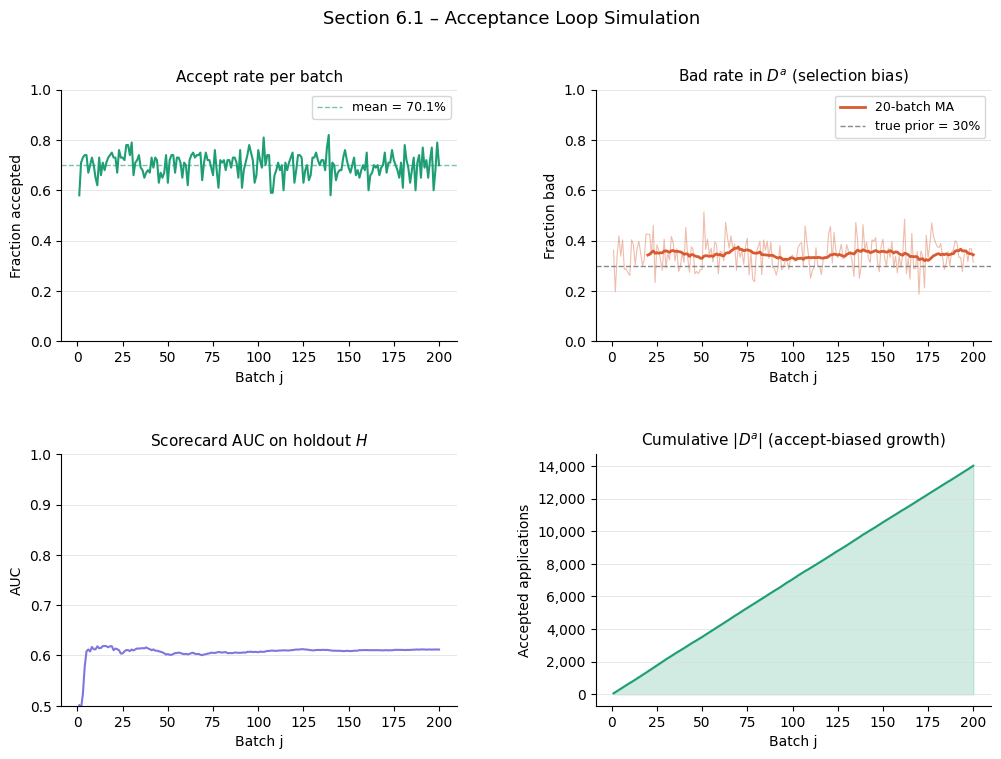

In [9]:

# ── Plots ─────────────────────────────────────────────────────────────────────
iterations = np.arange(1, J + 1)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Section 6.1 – Acceptance Loop Simulation", fontsize=13, y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# --- Panel 1: Accept rate over batches
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(iterations, accept_rates, color="#1D9E75", lw=1.5)
ax1.axhline(np.mean(accept_rates), color="#1D9E75", lw=1, ls="--", alpha=0.6,
            label=f"mean = {np.mean(accept_rates):.1%}")
ax1.set_title("Accept rate per batch", fontsize=11)
ax1.set_xlabel("Batch j")
ax1.set_ylabel("Fraction accepted")
ax1.set_ylim(0, 1)
ax1.legend(fontsize=9)

# --- Panel 2: Bad rate in D^a (selection bias)
ax2 = fig.add_subplot(gs[0, 1])
window = 20
bias_smooth = np.convolve(bias_rates, np.ones(window)/window, mode='valid')
ax2.plot(iterations, bias_rates, color="#D85A30", lw=0.8, alpha=0.4)
ax2.plot(iterations[window-1:], bias_smooth, color="#D85A30", lw=2,
         label=f"{window}-batch MA")
ax2.axhline(P_BAD, color="#888", lw=1, ls="--", label=f"true prior = {P_BAD:.0%}")
ax2.set_title("Bad rate in $D^a$ (selection bias)", fontsize=11)
ax2.set_xlabel("Batch j")
ax2.set_ylabel("Fraction bad")
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)

# --- Panel 3: Holdout AUC
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(iterations, holdout_aucs, color="#7F77DD", lw=1.5)
ax3.set_title("Scorecard AUC on holdout $H$", fontsize=11)
ax3.set_xlabel("Batch j")
ax3.set_ylabel("AUC")
ax3.set_ylim(0.5, 1.0)

# --- Panel 4: Cumulative size of D^a
cumulative_acc = np.cumsum([len(x) for x in D_a_X])
ax4 = fig.add_subplot(gs[1, 1])
ax4.fill_between(iterations, cumulative_acc, color="#1D9E75", alpha=0.2)
ax4.plot(iterations, cumulative_acc, color="#1D9E75", lw=1.5)
ax4.set_title("Cumulative $|D^a|$ (accept-biased growth)", fontsize=11)
ax4.set_xlabel("Batch j")
ax4.set_ylabel("Accepted applications")
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

for ax in [ax1, ax2, ax3, ax4]:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#ddd", lw=0.5)

plt.savefig("figures/acceptance_loop.png", dpi=150, bbox_inches="tight")
#plt.close()
print("Plot saved to acceptance_loop.png")